# Week 2 Assignment

### name: Lukas Linss
### student_id: 25332477
### id:7-7-7

In [34]:
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')


## Logistic Regression

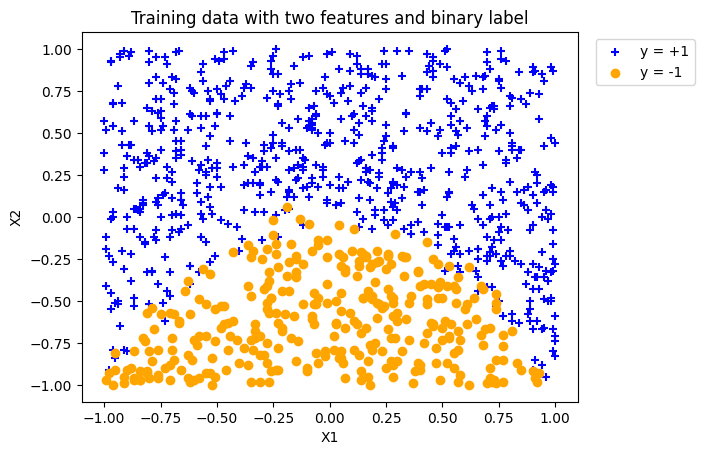

In [35]:
df = pd.read_csv('week_2_dataset.csv', skiprows=1, header=None, names=['X1', 'X2', 'Y'])

y_positive_df = df[df['Y'] == 1]
y_negative_df = df[df['Y'] == -1]

plt.scatter(x=y_positive_df['X1'], y=y_positive_df['X2'], color='blue', marker='+', label='y = +1')
plt.scatter(x=y_negative_df['X1'], y=y_negative_df['X2'], color='orange', marker='o', label='y = -1')

plt.title('Training data with two features and binary label')
plt.xlabel('X1')
plt.ylabel('X2')

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

prepare training and testing data

In [36]:
X = df[['X1', 'X2']].to_numpy()
y = df['Y'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

model = LogisticRegression(penalty=None, fit_intercept=True)
model.fit(x_train, y_train)
print(f"coefficients: {model.coef_[0]}, intercept: {model.intercept_[0]}")

pred = model.predict(x_test)
print(classification_report(y_test, pred))

coefficients: [0.68063794 6.41211645], intercept: 2.251272491275615
              precision    recall  f1-score   support

          -1       0.78      0.76      0.77       103
           1       0.88      0.89      0.88       197

    accuracy                           0.84       300
   macro avg       0.83      0.82      0.83       300
weighted avg       0.84      0.84      0.84       300



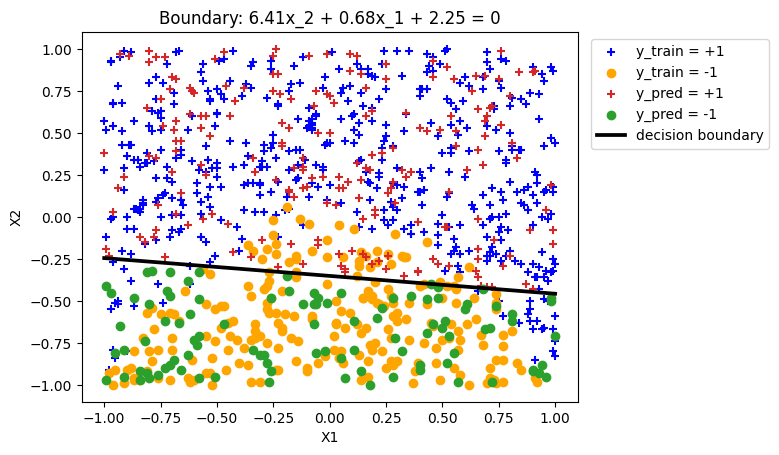

In [37]:
theta_0 = model.intercept_[0]
theta_1, theta_2 = model.coef_[0]

x2 = lambda x1: (-(theta_1 / theta_2) * x1 - (theta_0 / theta_2))

pos_train, neg_train = x_train[y_train == 1], x_train[y_train == -1]
pos_pred, neg_pred = x_test[pred == 1], x_test[pred == -1]

plt.scatter(x=pos_train.T[0], y=pos_train.T[1], color='blue', marker='+', label='y_train = +1')
plt.scatter(x=neg_train.T[0], y=neg_train.T[1], color='orange', marker='o', label='y_train = -1')

plt.scatter(x=pos_pred.T[0], y=pos_pred.T[1], marker='+', color='#d62728', label='y_pred = +1')
plt.scatter(x=neg_pred.T[0], y=neg_pred.T[1], marker='o', color='#2ca02c', label='y_pred = -1')

plt.plot([-1, 1], [x2(-1), x2(1)], color='black', linewidth='2.7', label='decision boundary')

plt.title(f'Boundary: {round(theta_2, 2)}x_2 + {round(theta_1, 2)}x_1 + {round(theta_0, 2)} = 0')
plt.xlabel('X1')
plt.ylabel('X2')

plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.show()